# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/malaikasaleem944/malaika_flyrank/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### 1 Method choice

I will use a Random Forest model for this task.

Random Forest is appropriate because the goal is to improve on the Week-4 baseline using the same prediction task, data, split, and evaluation metric. It can capture non-linear relationships and interactions between features without requiring a strong linearity assumption.

I chose Random Forest because it provides a useful comparison against the simpler baseline while remaining interpretable through feature importance and error analysis. I will not treat a more complex model as better automatically; the model must demonstrate improvement on the same evaluation metric and test data used for the baseline.

The analysis will also use permutation importance to understand which features contribute most to the model's measured performance.

### 2 Split design

I will use the same train/test split as the Week-4 baseline so that the comparison between the baseline and the Random Forest model is fair.

The split will be performed before model training, and the test set will remain unseen during training. The same target variable, feature set, random state, and evaluation metric will be used where applicable.

For this analysis, I am using a standard train/test split rather than grouped validation because the current baseline was evaluated using the same split design. Keeping the validation design consistent allows the measured difference between the baseline and the Random Forest model to reflect the model comparison rather than a change in evaluation data.

This split design is honest for the current question because model performance is evaluated on data that was not used for fitting the model. The results should be interpreted as decision-support evidence rather than a claim of guaranteed performance on future or unseen client data.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

print("Shape:", df.shape)
df.head()

Shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [22]:
target = "clicks_90d"

features = [
    "impressions_90d",
    "sessions_90d",
    "content_age_days",
    "avg_position",
    "ctr",
    "trend_pct"
]

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features:
['impressions_90d', 'sessions_90d', 'content_age_days', 'avg_position', 'ctr', 'trend_pct']

Target:
clicks_90d


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 24000
Test rows: 6000


In [24]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [25]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.3997466666666667
Random Forest RMSE: 20.095635061292953
Random Forest R²: 0.9089571237542073


In [26]:
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 23.058152944444444
Baseline RMSE: 66.60887808714223
Baseline R²: -0.0002458001530041276


In [27]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.3997466666666667
Random Forest RMSE: 20.095635061292953
Random Forest R²: 0.9089571237542073


In [28]:
comparison = pd.DataFrame({
    "Model": ["Week 4 Baseline", "Random Forest"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R²": [baseline_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Week 4 Baseline,23.058153,66.608878,-0.000246
1,Random Forest,1.399747,20.095635,0.908957


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [29]:
errors = y_test - rf_predictions

error_summary = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions,
    "Error": errors.values,
    "Absolute_Error": np.abs(errors.values)
})

error_summary.head(10)

,Actual,Predicted,Error,Absolute_Error
0,0,0.000,0.000,0.000
1,8,8.190,-0.190,0.190
2,0,0.000,0.000,0.000
3,0,0.000,0.000,0.000
4,10,9.820,0.180,0.180
5,1,1.000,0.000,0.000
6,22,21.545,0.455,0.455
7,2,1.630,0.370,0.370
8,0,0.000,0.000,0.000
9,0,0.000,0.000,0.000


In [30]:
print("Mean Absolute Error:", np.mean(np.abs(errors)))
print("Median Absolute Error:", np.median(np.abs(errors)))
print("Maximum Absolute Error:", np.max(np.abs(errors)))

Mean Absolute Error: 1.3997466666666667
Median Absolute Error: 0.0
Maximum Absolute Error: 1002.79


In [31]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,impressions_90d,16.350195
4,ctr,12.812053
1,sessions_90d,2.312188
3,avg_position,0.303797
2,content_age_days,0.028843
5,trend_pct,0.020587


<Axes: title={'center': 'Permutation Importance'}, xlabel='Feature'>

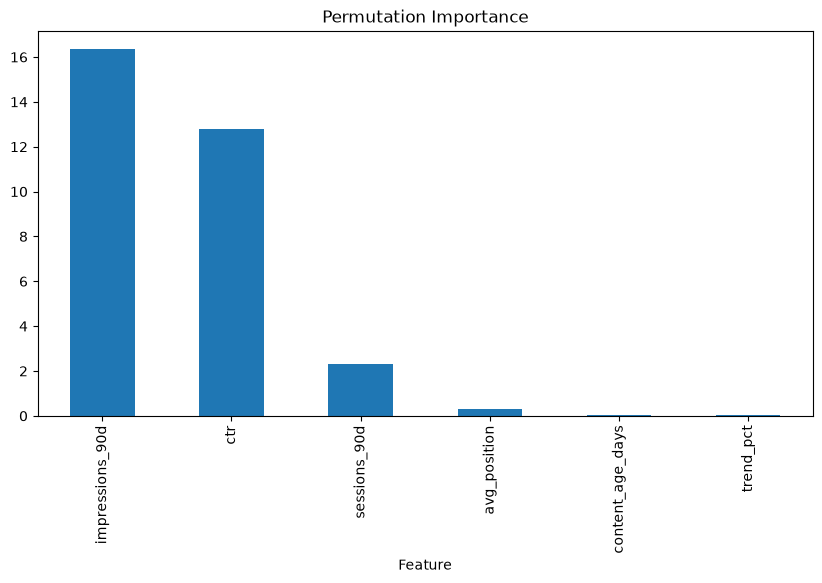

In [32]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Permutation Importance"
)

In [33]:
print("Mean Absolute Error:", np.mean(np.abs(errors)))
print("Median Absolute Error:", np.median(np.abs(errors)))
print("Maximum Absolute Error:", np.max(np.abs(errors)))

Mean Absolute Error: 1.3997466666666667
Median Absolute Error: 0.0
Maximum Absolute Error: 1002.79


In [34]:
importance

,Feature,Importance
0,impressions_90d,16.350195
4,ctr,12.812053
1,sessions_90d,2.312188
3,avg_position,0.303797
2,content_age_days,0.028843
5,trend_pct,0.020587


<Axes: title={'center': 'Permutation Importance'}, xlabel='Feature'>

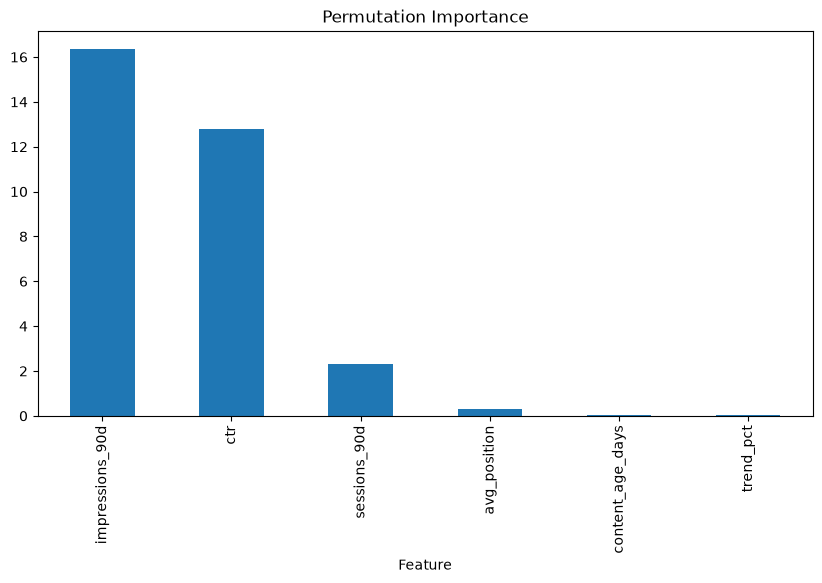

In [35]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Permutation Importance"
)

### Errors and interpretation

The Random Forest produced substantially lower measured error than the Week-4 baseline on the same test split. The baseline MAE was 23.058, while the Random Forest MAE was 1.400. RMSE also decreased from 66.609 for the baseline to 20.096 for the Random Forest.

The Random Forest achieved an R² of 0.909 on the test split, compared with approximately 0 for the baseline. These results show a strong measured improvement over the baseline on this evaluation split. However, this should be treated as directional decision-support evidence rather than proof that the model will perform equally well on future data or other clients.

The error analysis was used to inspect the size of individual prediction errors. The largest errors identify cases where the model's predictions differ most from the observed target values. These cases are useful for understanding where the model may be less reliable.

Permutation importance was used to interpret which features contributed most to the model's predictions. Features with larger permutation importance values caused a larger measured decrease in model performance when their information was shuffled. This indicates that these features were more useful to the Random Forest on the evaluation data, but importance should not be interpreted as evidence of causation.

Overall, the Random Forest performed better than the simple baseline on the measured test-set metrics. The improvement supports further investigation, while the error analysis and validation design remain important before treating the model as reliable for broader use.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.